# Manual STARFIT tuning — lower basin reservoirs

Tune the STARFIT rule parameters for FE Walter, Beltzville, Blue Marsh, and Prompton,
compare against observations, and repeat until the operations look right.

**How to iterate:** edit the `OVERRIDES` cell, then rerun every cell below it.

Quick refresher on the rule: STARFIT keeps a seasonal band of storage called the
normal operating range (NOR). Inside the band the reservoir follows a seasonal
release pattern; above the band it releases extra water to drain back down; below
the band it drops to the minimum release.

### The main functions

| Function | What it does |
|---|---|
| `load_observations()` | Loads observed storage and downstream gage flows through `pywrdrb.Data`. |
| `load_default_params()` | Reads the packaged `istarf_conus.csv` into a table, one row per reservoir. |
| `apply_overrides(...)` | Copies that table and swaps in the values you list in `OVERRIDES`. |
| `write_custom_csv(...)` | Saves the edited table to `output/custom_starfit_<TAG>.csv` for the model to read. |
| `plot_static_diagnostics(...)` | Draws the rule itself (NOR band and seasonal release) against observations. No simulation — instant. |
| `run_offline_sim(...)` | Standalone STARFIT simulation, runs in seconds. A quick preview only: it skips the FFMP and Trenton-target logic at Beltzville and Blue Marsh. |
| `run_pywrdrb_model(...)` | Full pywrdrb simulation (a few minutes). This is the real model. |
| `load_sim_results(...)` | Loads the run output files through `pywrdrb.Data`. |
| `plot_sim_vs_obs_storage/release(...)` | Compares each run against observations. |

### How the custom CSV works

`write_custom_csv()` writes a complete copy of `istarf_conus.csv` with your edits applied.
The model then reads this file everywhere it would normally read the default one
(release rules, reservoir capacities, initial storage). Two things to know:

- Blue Marsh, Beltzville, and FE Walter get their parameters from rows named
  `modified_blueMarsh`, `modified_beltzvilleCombined`, and `modified_fewalter`;
  Prompton uses the plain `prompton` row. `apply_overrides()` maps the names for
  you, so just write the normal reservoir names.
- `Release_min`/`Release_max` for FE Walter, Beltzville, and Blue Marsh are fixed
  DRBC rules hard-coded in `lower_basin_ffmp.py`, so those two columns only have an
  effect for Prompton.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

from utils.tuning_utils import *
from plotting_functions.starfit_plots import *

INFLOW_TYPE = "pub_nhmv10_BC_withObsScaled"
START, END = "1983-10-01", "2023-12-31"      # simulation period
OBS_START, OBS_END = "2004-01-01", END        # window for comparing against observations
OUTPUT_DIR = Path.cwd() / "output"

In [2]:
obs = load_observations()
default_params = load_default_params()
default_params.loc[[get_starfit_row_name(r) for r in RESERVOIRS], TUNABLE_COLS]

,NORhi_mu,NORhi_alpha,NORhi_beta,NORhi_min,NORhi_max,NORlo_mu,NORlo_alpha,NORlo_beta,NORlo_min,NORlo_max,...,Release_alpha2,Release_beta1,Release_beta2,Release_c,Release_p1,Release_p2,Release_max,Release_min,Adjusted_CAP_MG,Adjusted_MEANFLOW_MGD
reservoir,,,,,,,,,,,,,,,,,,,,,
modified_fewalter,15.08,0.00,-15.00,5.0,20.0,9.00,-1.00,-30.00,1.60,14.20,...,-0.0357,0.1302,-0.0248,-0.123,0.183,0.732,1.774,-0.804,35800.0000,137.230000
modified_beltzvilleCombined,100.00,0.00,0.00,-99999.0,inf,90.00,2.28,-0.56,85.00,91.00,...,-0.0585,0.1903,0.0050,-0.338,17.016,0.788,1.878,-0.807,13500.0000,116.541720
modified_blueMarsh,15.08,-0.23,-2.01,-99999.0,inf,12.58,0.20,-4.08,12.31,15.52,...,-0.0357,0.1302,-0.0248,-0.123,0.183,0.732,1.774,-0.804,42320.3544,200.124912
prompton,15.08,-0.23,-2.01,-99999.0,inf,12.58,0.20,-4.08,12.31,15.52,...,-0.0357,0.1302,-0.0248,-0.123,0.183,0.732,1.774,-0.804,27956.0200,83.491894


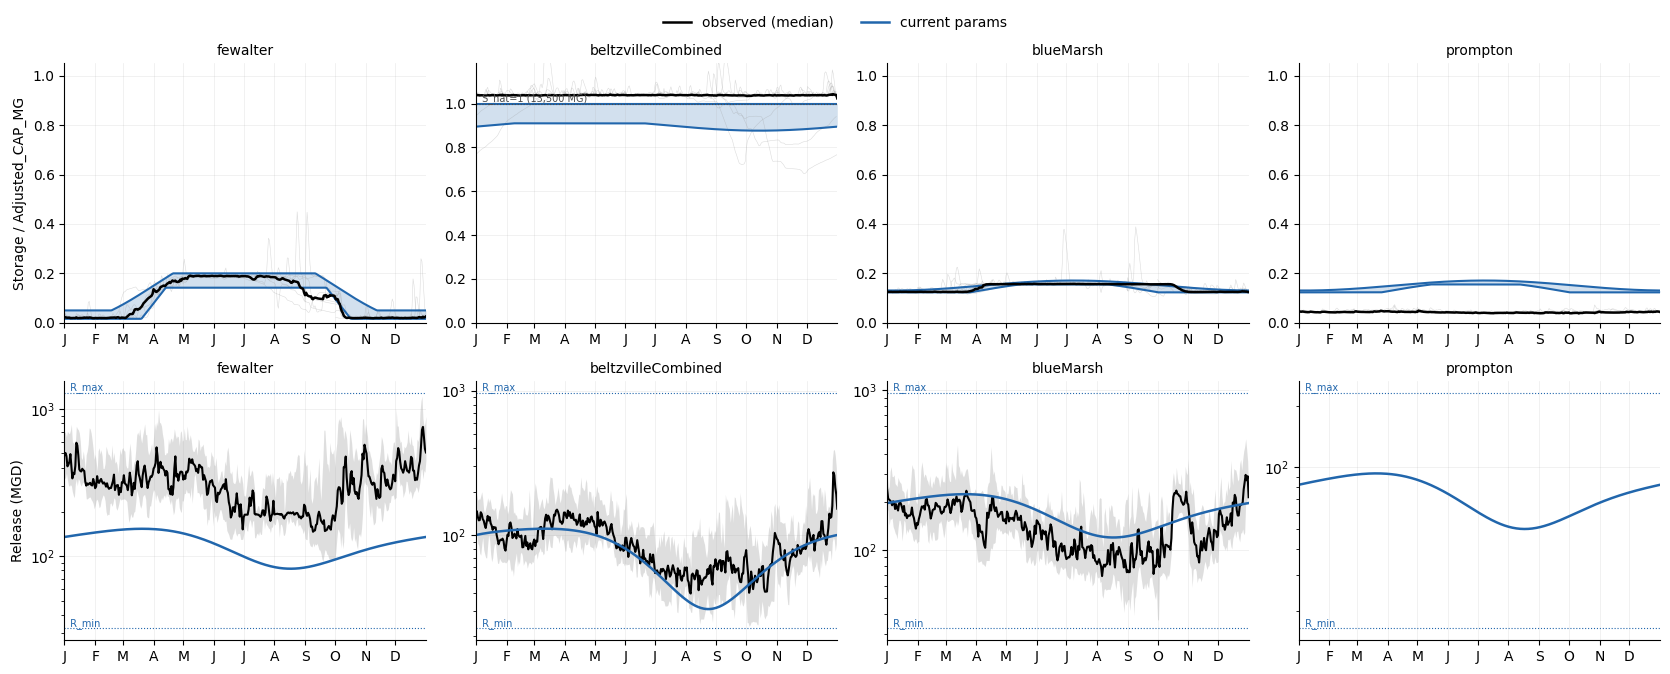

In [3]:
# The default rule vs observations. Top: NOR band with observed storage
# (thin lines are individual years, bold is the median). Bottom: seasonal
# release with the observed downstream flow. Nothing is simulated here.
fig = plot_static_diagnostics(default_params, RESERVOIRS, obs,
                              start=OBS_START, end=OBS_END)

In [6]:
# ============================== TUNING CELL ==============================
# Values here replace the defaults (defaults shown in comments).
# NOR bounds are in percent of Adjusted_CAP_MG: mu is the annual mean level,
# alpha/beta set the seasonal swing, min/max clip the band.

TAG = "v001"   # name for this parameter set; shows up in filenames and legends
OVERRIDES = {'fewalter':
 {'NORhi_mu': 46.08922398512882,
  'NORhi_min': 5.019849980486617,
  'NORhi_max': 19.162821474358225,
  'NORhi_alpha': 33.03118001811303,
  'NORhi_beta': -44.152237568338,
  'NORlo_mu': 0.6193982265654948,
  'NORlo_min': 1.000728310487557,
  'NORlo_max': 13.050487814051728,
  'NORlo_alpha': 7.8741399317491485,
  'NORlo_beta': -16.44229473955739,
  'Release_alpha1': 0.3854,
  'Release_alpha2': -0.3575,
  'Release_beta1': 0.4977,
  'Release_beta2': 0.0159,
  'Release_c': 1.1863,
  'Release_p1': 0.183,
  'Release_p2': 0.732},

  'beltzvilleCombined':
  {'NORhi_mu': 30.835557076026998,
   'NORhi_min': 109.01254484951215,
   'NORhi_max': 119.63659224545944,
   'NORhi_alpha': 32.461773425576787,
   'NORhi_beta': -30.75802302449903,
   'NORlo_mu': 100.5158523819703,
   'NORlo_min': 99.1188494047318,
   'NORlo_max': 99.81907933919445,
   'NORlo_alpha': 10.306734868890675,
   'NORlo_beta': -9.442870871978457,
   'Release_alpha1': 0.2686,
   'Release_alpha2': -0.0458,
   'Release_beta1': 0.1412,
   'Release_beta2': -0.0501,
   'Release_c': -0.2509,
   'Release_p1': 17.016,
   'Release_p2': 0.778},

   'blueMarsh':
   {'NORhi_mu': 24.4496722123068,
    'NORhi_min': 12.938195639100297,
    'NORhi_max': 15.80399122131035,
    'NORhi_alpha': -8.270382000625789,
    'NORhi_beta': -43.32012696784705,
    'NORlo_mu': 43.52222914030668,
    'NORlo_min': 11.673302917791558,
    'NORlo_max': 12.306757034706134,
    'NORlo_alpha': -7.474834438335775,
    'NORlo_beta': -2.645133005585148,
    'Release_alpha1': 0.1834,
    'Release_alpha2': -0.0102,
    'Release_beta1': 0.1713,
    'Release_beta2': -0.0104,
    'Release_c': -0.3006,
    'Release_p1': 0.183,
    'Release_p2': 0.732},

    'prompton':
    {'NORhi_mu': 23.520987178441764,
     'NORhi_min': 4.081116105119878,
     'NORhi_max': 4.568175178223056,
     'NORhi_alpha': 20.05526112466386,
     'NORhi_beta': 4.197975996709673,
     'NORlo_mu': 91.85890064531571,
     'NORlo_min': 1.0783270508635332,
     'NORlo_max': 3.5985866419211683,
     'NORlo_alpha': -7.965615152345211,
     'NORlo_beta': -6.493521989899466,
     'Release_alpha1': 0.2118,
     'Release_alpha2': -0.0357,
     'Release_beta1': 0.1302,
     'Release_beta2': -0.0248,
     'Release_c': -0.123,
     'Release_p1': 0.183,
     'Release_p2': 0.732}}

tuned_params = apply_overrides(default_params, OVERRIDES)
custom_csv = write_custom_csv(tuned_params, OUTPUT_DIR, tag=TAG)

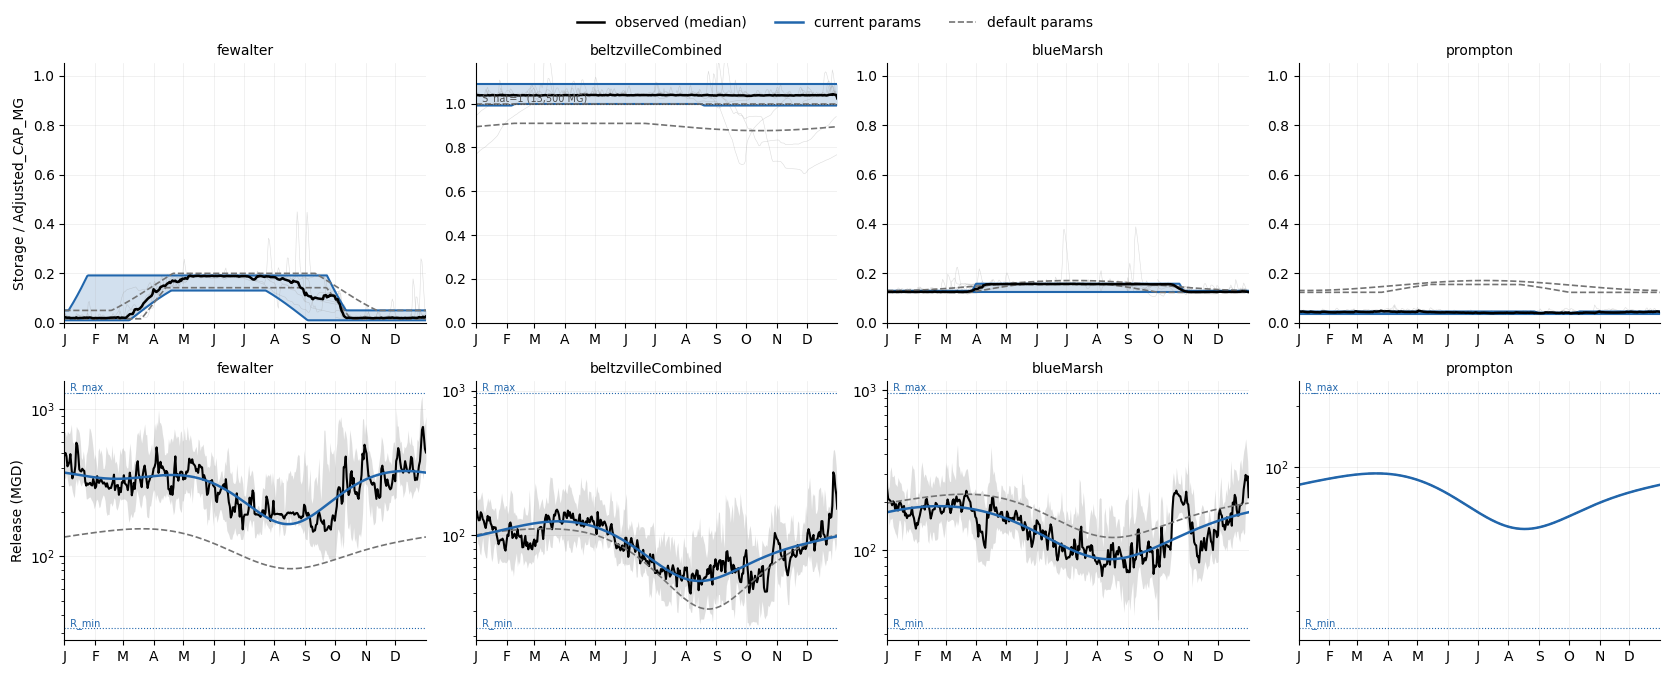

In [7]:
# Same plots with your edits (solid blue) next to the defaults (gray dashed).
fig = plot_static_diagnostics(tuned_params, RESERVOIRS, obs,
                              default_params_df=default_params,
                              start=OBS_START, end=OBS_END)

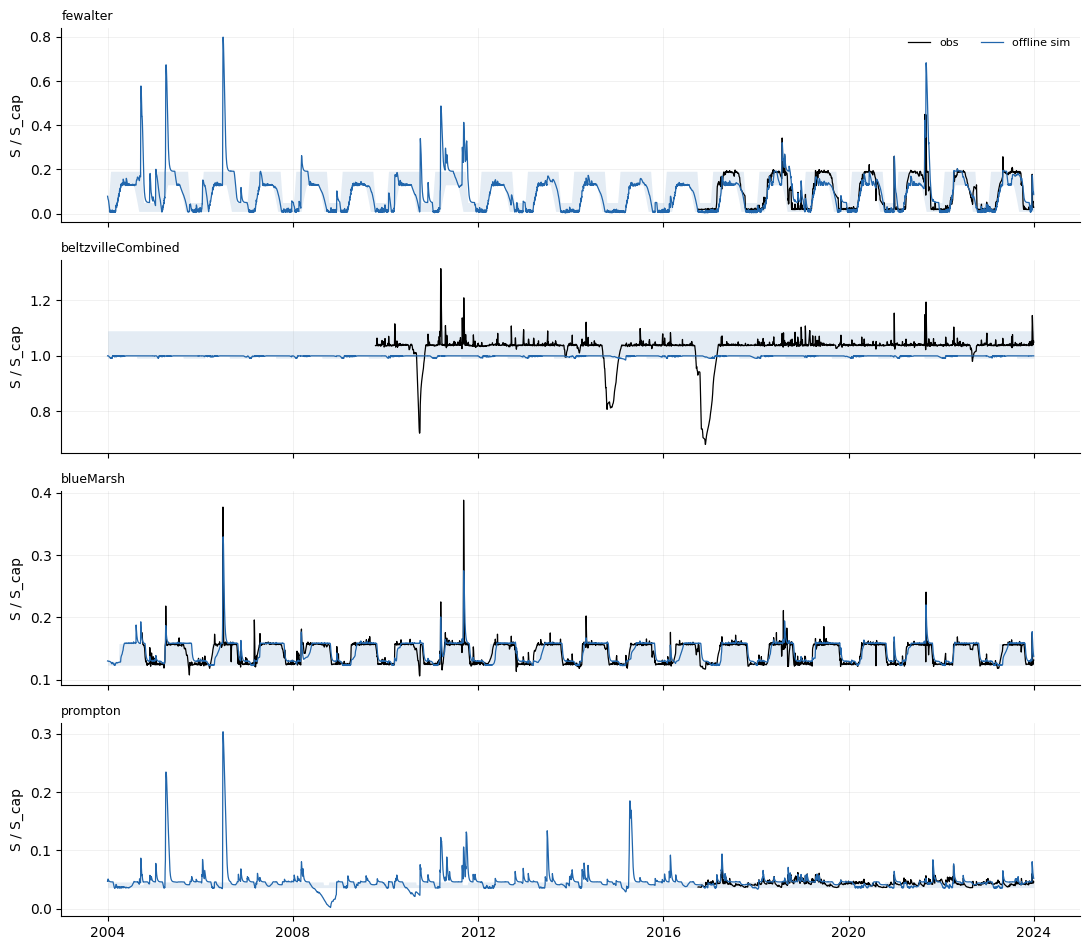

In [8]:
# Quick preview: standalone STARFIT simulation with the tuned CSV (seconds).
# Beltzville and Blue Marsh behave differently in the full model because of
# FFMP and Trenton-target releases, which this preview skips.
offline = run_offline_sim(INFLOW_TYPE, START, END, csv_path=custom_csv)
fig = plot_offline_sim(offline, tuned_params, obs, RESERVOIRS,
                       start=OBS_START, end=OBS_END)

In [9]:
# Full pywrdrb runs, a few minutes each. Both run fresh every time.
# Montague/Trenton flow forecasts use the perfect_foresight predictions.
baseline_h5 = run_pywrdrb_model("baseline_default", INFLOW_TYPE, START, END, OUTPUT_DIR)
tuned_h5 = run_pywrdrb_model(f"tuned_{TAG}", INFLOW_TYPE, START, END, OUTPUT_DIR,
                             csv_path=custom_csv)

c:\Users\tjame\Desktop\Research\DRB\Pywr-DRB\Pywr-DRB\venv\lib\site-packages\pywr\dataframe_tools.py:127: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  new_df = new_df.resample(target_index.freq).agg(resample_func)


Run complete: c:\Users\tjame\Desktop\Research\DRB\Pywr-DRB\Pywr-DRB\experiments\manual_starfit_tuning\output\baseline_default.hdf5


c:\Users\tjame\Desktop\Research\DRB\Pywr-DRB\Pywr-DRB\venv\lib\site-packages\pywr\dataframe_tools.py:127: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  new_df = new_df.resample(target_index.freq).agg(resample_func)


Run complete: c:\Users\tjame\Desktop\Research\DRB\Pywr-DRB\Pywr-DRB\experiments\manual_starfit_tuning\output\tuned_v001.hdf5


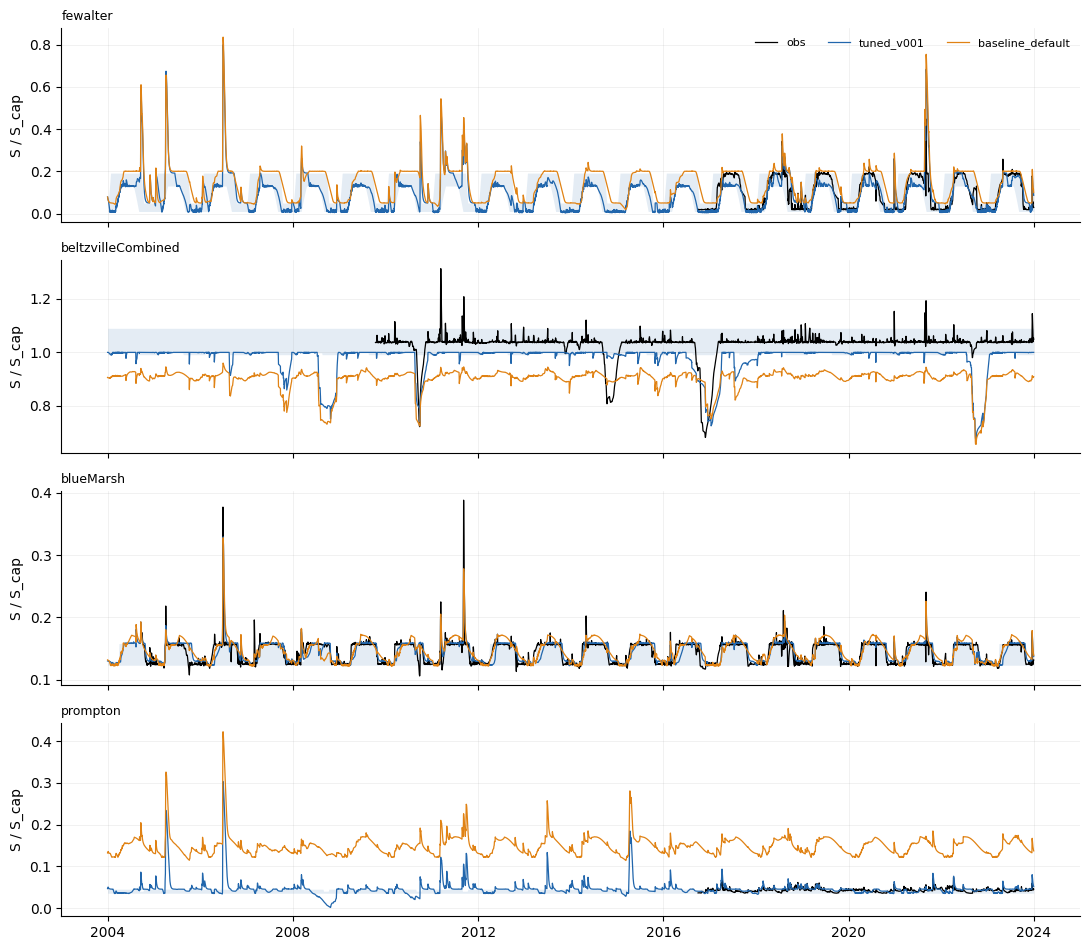

In [10]:
sim = load_sim_results([tuned_h5, baseline_h5])
RUN_LABELS = [f"tuned_{TAG}", "baseline_default"]

# Storage from both runs vs observed, with the tuned NOR band shaded.
fig = plot_sim_vs_obs_storage(sim, RUN_LABELS, RESERVOIRS, tuned_params, obs,
                              start=OBS_START, end=OBS_END)

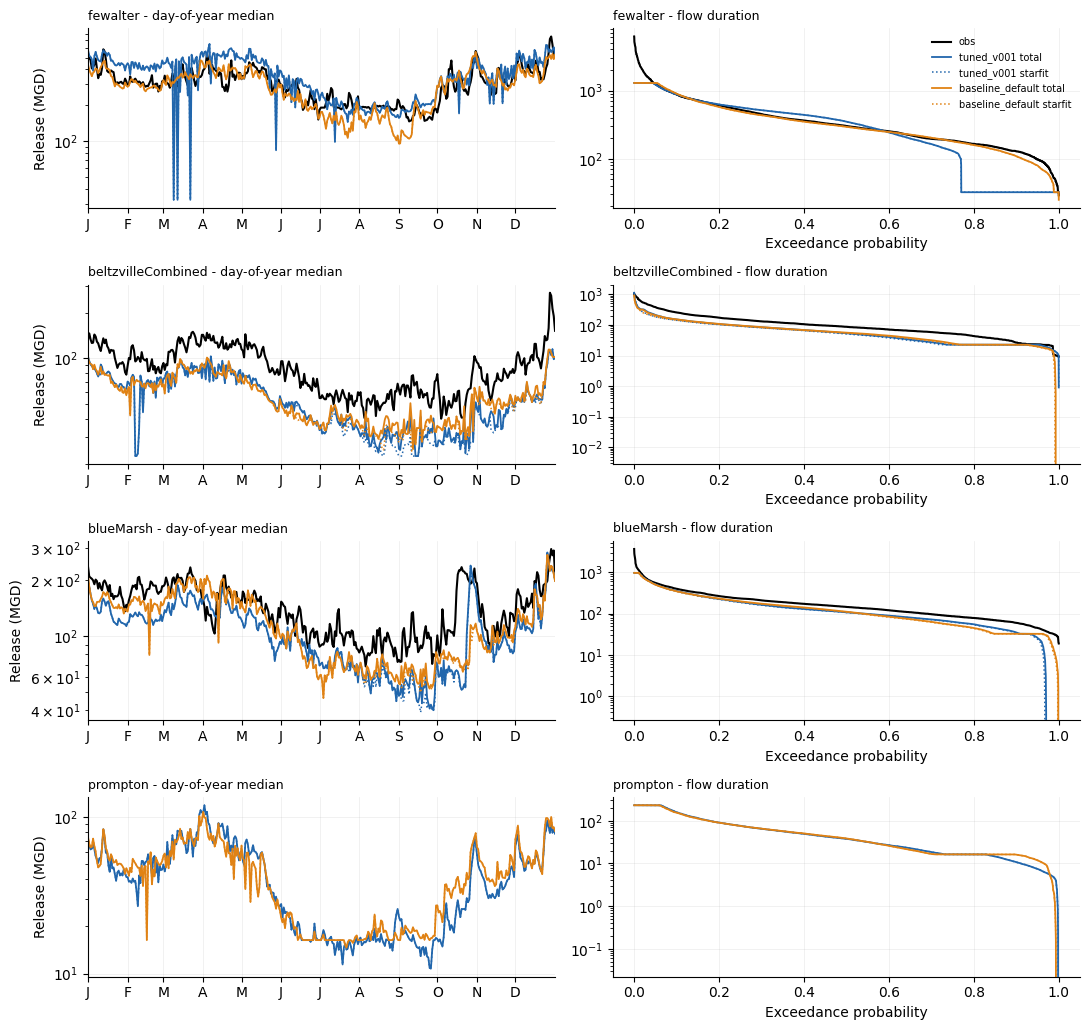

In [11]:
# Releases vs observed downstream flow. Solid = what actually leaves the
# reservoir (outflow + spill); dotted = what the STARFIT rule alone asked for.
# The gap between them at Beltzville and Blue Marsh is the FFMP/Trenton logic.
fig = plot_sim_vs_obs_release(sim, RUN_LABELS, RESERVOIRS, obs,
                              start=OBS_START, end=OBS_END)

In [12]:
# To keep a figure: savefig(fig, f"release_comparison_{TAG}")